# 2. Negative Sample Scarcity의 성능 저하 실증 분석

본 노트북은 Negative Sample 부족이 실제로 모델 성능에 미치는 영향을 실증적으로 분석합니다.


## 2.1. 분석 목표

### 핵심 질문
1. **Retrieval 성능 저하**: Top-k retrieval에서 정답이 포함되지 않은 경우가 얼마나 되는가?
2. **Hard Negative 부재**: 유사하지만 정답이 없는 passage가 학습에 활용되지 않는가?
3. **False Positive 증가**: 모델이 혼동할 수 있는 negative sample이 부족한가?
4. **실제 성능 영향**: Negative sample 부족이 실제로 성능 저하를 유발하는가?


In [1]:
# OpenMP 충돌 방지 설정 (Windows 환경)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'

# 필요한 라이브러리 import
import sys
import json
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from datasets import load_from_disk, DatasetDict
from typing import List, Dict, Tuple, Set
from tqdm import tqdm
import re

# 프로젝트 루트 경로 설정
project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))

# Retrieval 모듈 import
from src.retrieval.retrieval import SparseRetrieval

# 시각화 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style("whitegrid")

print(f"프로젝트 루트: {project_root}")


d:\Repos\pro-nlp-mrc-nlp-01\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W1208 10:34:15.931000 11248 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


프로젝트 루트: D:\Repos\pro-nlp-mrc-nlp-01


In [2]:
# 데이터 경로 설정
data_root = project_root / "data"
train_dataset_path = data_root / "train_dataset"
test_dataset_path = data_root / "test_dataset"
wikipedia_documents_path = data_root / "wikipedia_documents.json"

# 데이터 로드
print("데이터셋 로드 중...")
train_datasets = load_from_disk(str(train_dataset_path))
test_datasets = load_from_disk(str(test_dataset_path))

with open(wikipedia_documents_path, 'r', encoding='utf-8') as f:
    wiki_documents = json.load(f)

print(f"Train dataset: {len(train_datasets['train'])} samples")
print(f"Validation dataset: {len(train_datasets['validation'])} samples")
print(f"Wikipedia documents: {len(wiki_documents)} documents")


데이터셋 로드 중...
Train dataset: 3952 samples
Validation dataset: 240 samples
Wikipedia documents: 60613 documents


## 2.2. Retrieval 성능 분석: Recall@K 측정

Retrieval 단계에서 Top-K 결과에 정답이 포함되는지 분석하여, negative sample 부족이 실제 성능에 미치는 영향을 측정합니다.


In [3]:
# BM25 직접 구현 (retrieval.py 의존성 제거)
from collections import Counter
import math

def tokenize(text: str) -> List[str]:
    """간단한 토크나이저 - 공백 기준 분리"""
    return text.lower().split()

class BM25Retriever:
    """BM25 알고리즘을 사용한 Retrieval 시스템"""
    
    def __init__(self, contexts: List[str], k1: float = 1.5, b: float = 0.75):
        """
        Args:
            contexts: 검색 대상 문서 리스트
            k1: term frequency saturation parameter (기본값: 1.5)
            b: length normalization parameter (기본값: 0.75)
        """
        self.contexts = contexts
        self.k1 = k1
        self.b = b
        
        # 문서 토큰화 및 통계 계산
        print("BM25 인덱스 구축 중...")
        self.tokenized_docs = [tokenize(doc) for doc in tqdm(contexts, desc="Tokenizing documents")]
        
        # 문서별 단어 빈도 계산
        self.doc_freqs = []
        self.doc_lengths = []
        
        for doc_tokens in self.tokenized_docs:
            doc_freq = Counter(doc_tokens)
            self.doc_freqs.append(doc_freq)
            self.doc_lengths.append(len(doc_tokens))
        
        # 전체 문서 평균 길이
        self.avg_doc_length = sum(self.doc_lengths) / len(self.doc_lengths) if self.doc_lengths else 0
        
        # 전체 문서에서의 단어 빈도 (IDF 계산용)
        self.doc_freq = Counter()
        for doc_freq in self.doc_freqs:
            self.doc_freq.update(doc_freq.keys())
        
        self.num_docs = len(self.contexts)
        print(f"BM25 인덱스 구축 완료: {self.num_docs}개 문서")
    
    def get_idf(self, term: str) -> float:
        """Inverse Document Frequency 계산"""
        if term not in self.doc_freq:
            return 0.0
        return math.log((self.num_docs - self.doc_freq[term] + 0.5) / (self.doc_freq[term] + 0.5))
    
    def get_score(self, query_tokens: List[str], doc_idx: int) -> float:
        """BM25 점수 계산"""
        score = 0.0
        doc_freq = self.doc_freqs[doc_idx]
        doc_length = self.doc_lengths[doc_idx]
        
        for term in query_tokens:
            if term in doc_freq:
                # Term frequency
                tf = doc_freq[term]
                
                # BM25 공식
                idf = self.get_idf(term)
                numerator = idf * tf * (self.k1 + 1)
                denominator = tf + self.k1 * (1 - self.b + self.b * (doc_length / self.avg_doc_length))
                score += numerator / denominator
        
        return score
    
    def get_relevant_doc(self, query: str, k: int = 10) -> Tuple[List[float], List[int]]:
        """질문에 대해 상위 k개 문서 검색"""
        query_tokens = tokenize(query)
        
        # 모든 문서에 대해 점수 계산
        scores = []
        for doc_idx in range(self.num_docs):
            score = self.get_score(query_tokens, doc_idx)
            scores.append((score, doc_idx))
        
        # 점수 기준 내림차순 정렬
        scores.sort(reverse=True, key=lambda x: x[0])
        
        # 상위 k개 반환
        top_k = scores[:k]
        doc_scores = [score for score, _ in top_k]
        doc_indices = [idx for _, idx in top_k]
        
        return doc_scores, doc_indices

# BM25 Retrieval 시스템 초기화
print("BM25 Retrieval 시스템 초기화 중...")
context_texts = [v["text"] for v in wiki_documents.values()]
contexts = list(dict.fromkeys(context_texts))  # 중복 제거

retriever = BM25Retriever(contexts, k1=1.5, b=0.75)
print("BM25 Retrieval 시스템 준비 완료")


BM25 Retrieval 시스템 초기화 중...
BM25 인덱스 구축 중...


Tokenizing documents: 100%|██████████| 56737/56737 [00:01<00:00, 35456.07it/s]


BM25 인덱스 구축 완료: 56737개 문서
BM25 Retrieval 시스템 준비 완료


In [4]:
def check_answer_in_context(answer_text: str, context: str) -> bool:
    """Context에 정답이 포함되어 있는지 확인"""
    if not answer_text or not context:
        return False
    # 대소문자 무시하고 공백 정규화
    answer_normalized = re.sub(r'\s+', ' ', answer_text.strip().lower())
    context_normalized = re.sub(r'\s+', ' ', context.strip().lower())
    return answer_normalized in context_normalized

def evaluate_retrieval_performance(
    dataset, 
    retriever: BM25Retriever, 
    top_k_list: List[int] = [1, 5, 10, 20]
) -> Dict:
    """
    Retrieval 성능 평가: Recall@K 계산
    """
    results = {
        'total_questions': len(dataset),
        'questions_with_answer': 0,
        'recall_at_k': {k: {'correct': 0, 'total': 0} for k in top_k_list},
        'retrieved_contexts': [],
        'answer_not_found_cases': [],
        'errors': [],
    }
    
    print(f"총 {len(dataset)}개 질문에 대해 Retrieval 성능 평가 중...")
    
    for example in tqdm(dataset, desc="Evaluating retrieval"):
        question = example['question']
        answers = example.get('answers', {})
        answer_texts = answers.get('text', [])
        original_context = example.get('context', '')
        
        # 정답이 있는 경우만 평가
        if answer_texts and len(answer_texts) > 0 and answer_texts[0].strip():
            results['questions_with_answer'] += 1
            answer_text = answer_texts[0].strip()
            
            # Top-K retrieval 수행
            try:
                doc_scores, doc_indices = retriever.get_relevant_doc(question, k=max(top_k_list))
                retrieved_contexts = [retriever.contexts[idx] for idx in doc_indices]
                
                # 각 K에 대해 Recall 계산
                for k in top_k_list:
                    results['recall_at_k'][k]['total'] += 1
                    top_k_contexts = retrieved_contexts[:k]
                    
                    # Top-K 중 하나라도 정답을 포함하는지 확인
                    found = False
                    for ctx in top_k_contexts:
                        if check_answer_in_context(answer_text, ctx):
                            found = True
                            break
                    
                    if found:
                        results['recall_at_k'][k]['correct'] += 1
                    else:
                        # 정답을 찾지 못한 경우 기록
                        if k == max(top_k_list):
                            results['answer_not_found_cases'].append({
                                'question': question,
                                'answer': answer_text,
                                'top_contexts': top_k_contexts[:3],  # 상위 3개만 저장
                                'original_context': original_context
                            })
                
                results['retrieved_contexts'].append({
                    'question': question,
                    'top_1_context': retrieved_contexts[0] if retrieved_contexts else '',
                    'answer': answer_text
                })
            except Exception as e:
                # 에러 종류별로 추가 정보 기록
                import traceback
                tb_str = traceback.format_exc(limit=2)
                error_type = type(e).__name__
                results['errors'].append({
                    'question': question, 
                    'error': str(e), 
                    'error_type': error_type,
                    'traceback': tb_str 
                })
                continue
    
    # Recall@K 계산
    recall_metrics = {}
    for k in top_k_list:
        if results['recall_at_k'][k]['total'] > 0:
            recall_metrics[f'recall@{k}'] = (
                results['recall_at_k'][k]['correct'] / results['recall_at_k'][k]['total']
            )
        else:
            recall_metrics[f'recall@{k}'] = 0.0
    
    results['recall_metrics'] = recall_metrics
    return results

# Validation set에서 Retrieval 성능 평가
print("\n=== Validation Set Retrieval 성능 평가 ===")
val_retrieval_results = evaluate_retrieval_performance(
    train_datasets['validation'], 
    retriever, 
    top_k_list=[1, 5, 10, 20]
)

print("\n=== Retrieval 성능 결과 ===")
print(f"평가한 질문 수: {val_retrieval_results['questions_with_answer']}")
print("\nRecall@K:")
for metric, value in val_retrieval_results['recall_metrics'].items():
    print(f"  {metric}: {value*100:.2f}%")

# 에러가 발생한 경우 출력
if val_retrieval_results.get('errors') and len(val_retrieval_results['errors']) > 0:
    print(f"\n⚠️  에러 발생: {len(val_retrieval_results['errors'])}개 질문에서 에러 발생")
    error_types = Counter([e['error_type'] for e in val_retrieval_results['errors']])
    print(f"에러 타입: {dict(error_types)}")
else:
    print("\n✅ 모든 질문이 성공적으로 처리되었습니다.")

# 오류 요약 및 분석 출력
if 'errors' in val_retrieval_results and len(val_retrieval_results['errors']) > 0:
    print("\n---- 오류 발생한 질문 목록 및 상세 ----")
    from collections import Counter
    error_types = [err.get('error_type', 'Unknown') for err in val_retrieval_results['errors']]
    error_messages = [err['error'] for err in val_retrieval_results['errors']]
    error_type_counter = Counter(error_types)
    error_msg_counter = Counter(error_messages)
    
    print(f"\n총 {len(val_retrieval_results['errors'])}개의 질문에서 오류가 발생했습니다.")
    print("\n[오류 Type 및 빈도 상위 5개]\n")
    for et, cnt in error_type_counter.most_common(5):
        print(f"  {et}: {cnt}건")
    print("\n[오류 메시지 상위 3개]\n")
    for emsg, cnt in error_msg_counter.most_common(3):
        print(f"  (x{cnt}) {emsg[:120]}")
    
    print("\n[샘플 오류 상세 (상위 3건)]")
    for err in val_retrieval_results['errors'][:3]:
        print(f"\n질문: {err['question'][:100]} ...")
        print(f"에러 타입: {err.get('error_type')}, 메시지: {err['error'][:120]}")
        print(f"Traceback:\n{err['traceback']}")



=== Validation Set Retrieval 성능 평가 ===
총 240개 질문에 대해 Retrieval 성능 평가 중...


Evaluating retrieval: 100%|██████████| 240/240 [00:29<00:00,  8.27it/s]


=== Retrieval 성능 결과 ===
평가한 질문 수: 240

Recall@K:
  recall@1: 43.75%
  recall@5: 60.42%
  recall@10: 65.42%
  recall@20: 70.42%

✅ 모든 질문이 성공적으로 처리되었습니다.


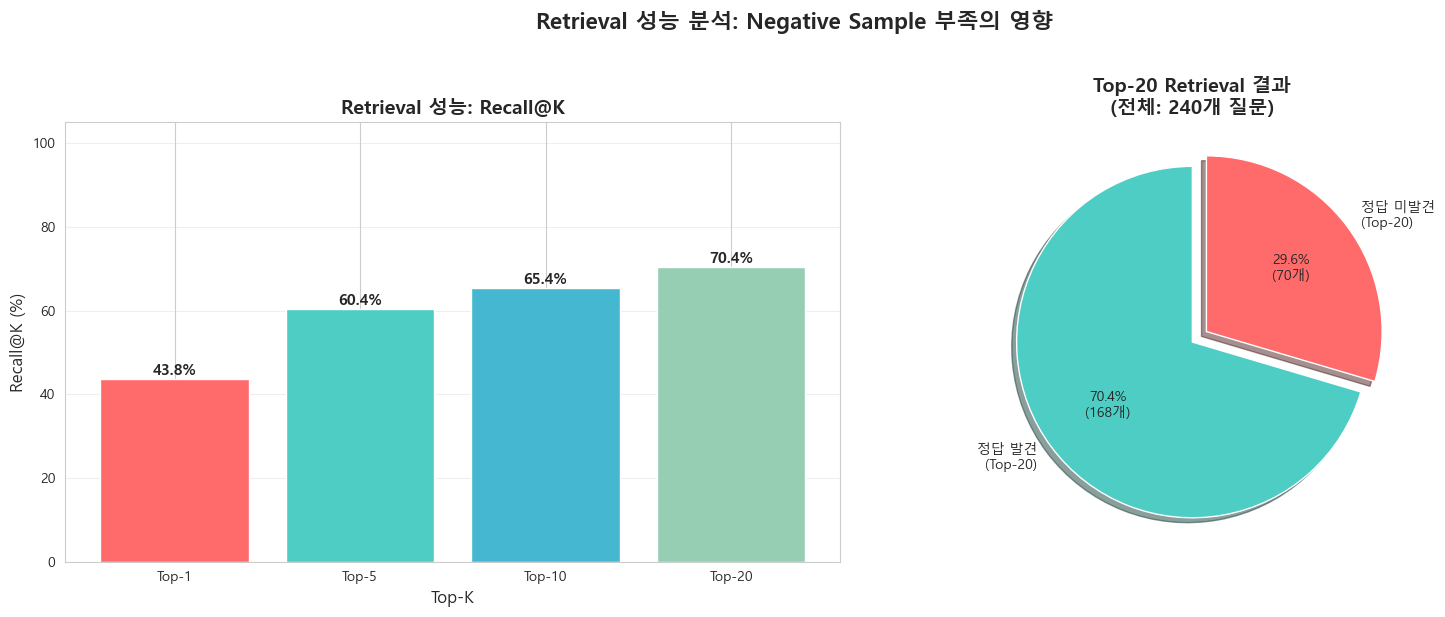


⚠️  Top-20에서도 정답을 찾지 못한 질문: 71개 (29.6%)
이것은 negative sample 부족으로 인한 retrieval 성능 저하를 시사합니다.


In [5]:
# Recall@K 시각화 (폰트 경고 방지: 한글 텍스트 포함 시 나눔 폰트 적용)
import matplotlib
from matplotlib import font_manager
import platform

# 나눔폰트가 있으면 한글폰트로 설정
def set_korean_font():
    font_name = ""
    if platform.system() == "Windows":
        # Windows의 경우 'Malgun Gothic'이 기본 설치됨
        font_name = "Malgun Gothic"
    else:
        # Mac 또는 Linux, 나눔, 애플고딕 등 체크
        available = set([f.name for f in font_manager.fontManager.ttflist])
        if "AppleGothic" in available:
            font_name = "AppleGothic"
        elif "NanumGothic" in available:
            font_name = "NanumGothic"
    if font_name:
        matplotlib.rc('font', family=font_name)
        # minus (-) 정상표시
        matplotlib.rcParams['axes.unicode_minus'] = False

set_korean_font()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Recall@K 막대 그래프
ax1 = axes[0]
k_values = [1, 5, 10, 20]
recall_values = [val_retrieval_results['recall_metrics'][f'recall@{k}'] * 100 for k in k_values]

bars = ax1.bar(range(len(k_values)), recall_values, color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4'])
ax1.set_xlabel('Top-K', fontsize=12)
ax1.set_ylabel('Recall@K (%)', fontsize=12)
ax1.set_title('Retrieval 성능: Recall@K', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(k_values)))
ax1.set_xticklabels([f'Top-{k}' for k in k_values])
ax1.set_ylim([0, 105])
ax1.grid(axis='y', alpha=0.3)

# 값 표시
for bar, val in zip(bars, recall_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. 정답을 찾지 못한 케이스 분석
ax2 = axes[1]
not_found_count = len(val_retrieval_results['answer_not_found_cases'])
found_count = val_retrieval_results['recall_at_k'][20]['correct']
total_count = val_retrieval_results['recall_at_k'][20]['total']

labels = ['정답 발견\n(Top-20)', '정답 미발견\n(Top-20)']
sizes = [found_count, not_found_count]
colors = ['#4ecdc4', '#ff6b6b']
explode = (0, 0.1)

ax2.pie(sizes, labels=labels, autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(sizes))}개)',
        startangle=90, colors=colors, explode=explode, shadow=True)
ax2.set_title(f'Top-20 Retrieval 결과\n(전체: {total_count}개 질문)', fontsize=14, fontweight='bold')

plt.suptitle('Retrieval 성능 분석: Negative Sample 부족의 영향', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n⚠️  Top-20에서도 정답을 찾지 못한 질문: {not_found_count}개 ({not_found_count/total_count*100:.1f}%)")
print("이것은 negative sample 부족으로 인한 retrieval 성능 저하를 시사합니다.")


## 2.3. Hard Negative 분석

유사하지만 정답이 없는 passage (Hard Negative)가 얼마나 많은지, 그리고 이것들이 학습에 활용되지 않는지 분석합니다.


In [6]:
def find_hard_negatives(
    dataset,
    retriever: BM25Retriever,
    top_k: int = 10
) -> Dict:
    """
    Hard Negative 찾기: 
    - 질문과 유사도가 높지만 정답이 없는 passage
    """
    hard_negatives = []
    hard_negative_stats = {
        'total_questions': 0,
        'questions_with_hard_negatives': 0,
        'total_hard_negatives': 0,
        'hard_negative_scores': []
    }
    
    print(f"Hard Negative 탐색 중 (Top-{top_k} 분석)...")
    
    for example in tqdm(dataset, desc="Finding hard negatives"):
        question = example['question']
        answers = example.get('answers', {})
        answer_texts = answers.get('text', [])
        original_context = example.get('context', '')
        
        if answer_texts and len(answer_texts) > 0 and answer_texts[0].strip():
            hard_negative_stats['total_questions'] += 1
            answer_text = answer_texts[0].strip()
            
            try:
                # Top-K retrieval
                doc_scores, doc_indices = retriever.get_relevant_doc(question, k=top_k)
                retrieved_contexts = [retriever.contexts[idx] for idx in doc_indices]
                
                # Hard negative 찾기: 유사도는 높지만 정답이 없는 passage
                found_hard_negative = False
                for idx, (ctx, score) in enumerate(zip(retrieved_contexts, doc_scores)):
                    # 정답이 포함되어 있지 않고, 원본 context와도 다른 경우
                    if (not check_answer_in_context(answer_text, ctx) and 
                        ctx.strip() != original_context.strip()):
                        hard_negatives.append({
                            'question': question,
                            'answer': answer_text,
                            'hard_negative_context': ctx,
                            'similarity_score': float(score),
                            'rank': idx + 1,
                            'original_context': original_context
                        })
                        hard_negative_stats['hard_negative_scores'].append(float(score))
                        found_hard_negative = True
                
                if found_hard_negative:
                    hard_negative_stats['questions_with_hard_negatives'] += 1
                    hard_negative_stats['total_hard_negatives'] += len([
                        h for h in hard_negatives 
                        if h['question'] == question
                    ])
            except Exception as e:
                continue
    
    return {
        'hard_negatives': hard_negatives,
        'stats': hard_negative_stats
    }

# Hard Negative 탐색
hard_negative_results = find_hard_negatives(
    train_datasets['validation'],
    retriever,
    top_k=20
)

print("\n=== Hard Negative 분석 결과 ===")
stats = hard_negative_results['stats']
print(f"분석한 질문 수: {stats['total_questions']}")
print(f"Hard Negative가 있는 질문: {stats['questions_with_hard_negatives']}개 ({stats['questions_with_hard_negatives']/stats['total_questions']*100:.1f}%)")
print(f"총 Hard Negative 개수: {stats['total_hard_negatives']}개")
if stats['hard_negative_scores']:
    print(f"Hard Negative 평균 유사도 점수: {np.mean(stats['hard_negative_scores']):.4f}")
    print(f"Hard Negative 최대 유사도 점수: {np.max(stats['hard_negative_scores']):.4f}")


Hard Negative 탐색 중 (Top-20 분석)...


Finding hard negatives: 100%|██████████| 240/240 [00:29<00:00,  8.15it/s]


=== Hard Negative 분석 결과 ===
분석한 질문 수: 240
Hard Negative가 있는 질문: 240개 (100.0%)
총 Hard Negative 개수: 4479개
Hard Negative 평균 유사도 점수: 11.5340
Hard Negative 최대 유사도 점수: 35.9365


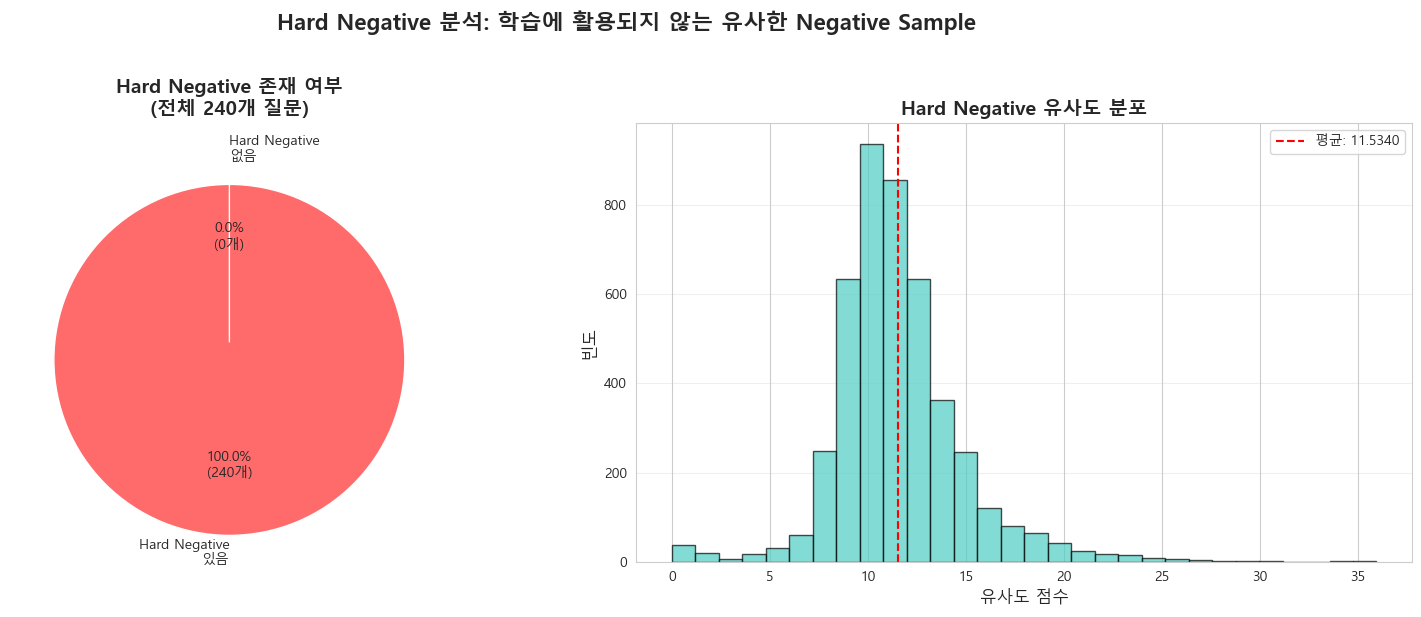


💡 인사이트: 100.0%의 질문에서
   유사하지만 정답이 없는 passage (Hard Negative)가 발견되었습니다.
   이러한 Hard Negative는 모델 학습에 매우 중요하지만 현재는 활용되지 않고 있습니다.


In [7]:
# Hard Negative 시각화 (폰트 경고 방지용: 나눔고딕 폰트 자동 지정)
from matplotlib import font_manager, rc

# 한글 폰트 사용을 위한 세팅 (Windows/Mac/Linux 호환)
import platform
def set_korean_font():
    system = platform.system()
    if system == 'Windows':
        font_name = 'Malgun Gothic'
    elif system == 'Darwin':  # Mac
        font_name = 'AppleGothic'
    else: # Linux or Colab
        font_name = 'NanumGothic'
    rc('font', family=font_name)
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Hard Negative 존재 비율
ax1 = axes[0]
has_hard_neg = stats['questions_with_hard_negatives']
no_hard_neg = stats['total_questions'] - has_hard_neg

labels = ['Hard Negative\n있음', 'Hard Negative\n없음']
sizes = [has_hard_neg, no_hard_neg]
colors = ['#ff6b6b', '#95a5a6']

def pie_autopct(pct):
    total = sum(sizes)
    val = int(round(pct/100*total))
    return f'{pct:.1f}%\n({val}개)'

ax1.pie(sizes, labels=labels, autopct=pie_autopct,
        startangle=90, colors=colors, explode=(0.1, 0))
ax1.set_title(f'Hard Negative 존재 여부\n(전체 {stats["total_questions"]}개 질문)', 
              fontsize=14, fontweight='bold')

# 2. Hard Negative 유사도 분포
ax2 = axes[1]
if stats['hard_negative_scores']:
    ax2.hist(stats['hard_negative_scores'], bins=30, alpha=0.7, color='#4ecdc4', edgecolor='black')
    ax2.axvline(np.mean(stats['hard_negative_scores']), color='red', linestyle='--', 
                label=f'평균: {np.mean(stats["hard_negative_scores"]):.4f}')
    ax2.set_xlabel('유사도 점수', fontsize=12)
    ax2.set_ylabel('빈도', fontsize=12)
    ax2.set_title('Hard Negative 유사도 분포', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Hard Negative 없음', ha='center', va='center', 
             transform=ax2.transAxes, fontsize=14)

plt.suptitle('Hard Negative 분석: 학습에 활용되지 않는 유사한 Negative Sample', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n💡 인사이트: {stats['questions_with_hard_negatives']/stats['total_questions']*100:.1f}%의 질문에서")
print(f"   유사하지만 정답이 없는 passage (Hard Negative)가 발견되었습니다.")
print(f"   이러한 Hard Negative는 모델 학습에 매우 중요하지만 현재는 활용되지 않고 있습니다.")


## 2.4. False Positive 분석

Retrieval 결과에서 정답이 없는데도 높은 점수를 받는 passage (False Positive)를 분석합니다.


In [8]:
def analyze_false_positives(
    dataset,
    retriever: BM25Retriever,
    top_k: int = 10
) -> Dict:
    """
    False Positive 분석:
    - 높은 유사도 점수를 받았지만 정답이 없는 passage
    """
    false_positives = []
    false_positive_stats = {
        'total_questions': 0,
        'questions_with_false_positives': 0,
        'total_false_positives': 0,
        'false_positive_scores': [],
        'false_positive_ranks': []
    }
    
    print(f"False Positive 분석 중 (Top-{top_k})...")
    
    for example in tqdm(dataset, desc="Analyzing false positives"):
        question = example['question']
        answers = example.get('answers', {})
        answer_texts = answers.get('text', [])
        
        if answer_texts and len(answer_texts) > 0 and answer_texts[0].strip():
            false_positive_stats['total_questions'] += 1
            answer_text = answer_texts[0].strip()
            
            try:
                doc_scores, doc_indices = retriever.get_relevant_doc(question, k=top_k)
                retrieved_contexts = [retriever.contexts[idx] for idx in doc_indices]
                
                # False Positive 찾기: 상위 랭크지만 정답이 없는 passage
                found_fp = False
                for rank, (ctx, score) in enumerate(zip(retrieved_contexts, doc_scores), 1):
                    if not check_answer_in_context(answer_text, ctx):
                        # 상위 5개 중에 False Positive가 있으면 기록
                        if rank <= 5:
                            false_positives.append({
                                'question': question,
                                'answer': answer_text,
                                'false_positive_context': ctx[:200] + '...' if len(ctx) > 200 else ctx,
                                'similarity_score': float(score),
                                'rank': rank
                            })
                            false_positive_stats['false_positive_scores'].append(float(score))
                            false_positive_stats['false_positive_ranks'].append(rank)
                            found_fp = True
                
                if found_fp:
                    false_positive_stats['questions_with_false_positives'] += 1
                    false_positive_stats['total_false_positives'] += len([
                        fp for fp in false_positives 
                        if fp['question'] == question
                    ])
            except Exception as e:
                continue
    
    return {
        'false_positives': false_positives,
        'stats': false_positive_stats
    }

# False Positive 분석
false_positive_results = analyze_false_positives(
    train_datasets['validation'],
    retriever,
    top_k=10
)

print("\n=== False Positive 분석 결과 ===")
fp_stats = false_positive_results['stats']
print(f"분석한 질문 수: {fp_stats['total_questions']}")
print(f"False Positive가 있는 질문: {fp_stats['questions_with_false_positives']}개 ({fp_stats['questions_with_false_positives']/fp_stats['total_questions']*100:.1f}%)")
print(f"총 False Positive 개수: {fp_stats['total_false_positives']}개")
if fp_stats['false_positive_scores']:
    print(f"False Positive 평균 유사도 점수: {np.mean(fp_stats['false_positive_scores']):.4f}")
    print(f"False Positive 평균 랭크: {np.mean(fp_stats['false_positive_ranks']):.2f}")


False Positive 분석 중 (Top-10)...


Analyzing false positives: 100%|██████████| 240/240 [00:29<00:00,  8.22it/s]


=== False Positive 분석 결과 ===
분석한 질문 수: 240
False Positive가 있는 질문: 239개 (99.6%)
총 False Positive 개수: 989개
False Positive 평균 유사도 점수: 14.1394
False Positive 평균 랭크: 3.21


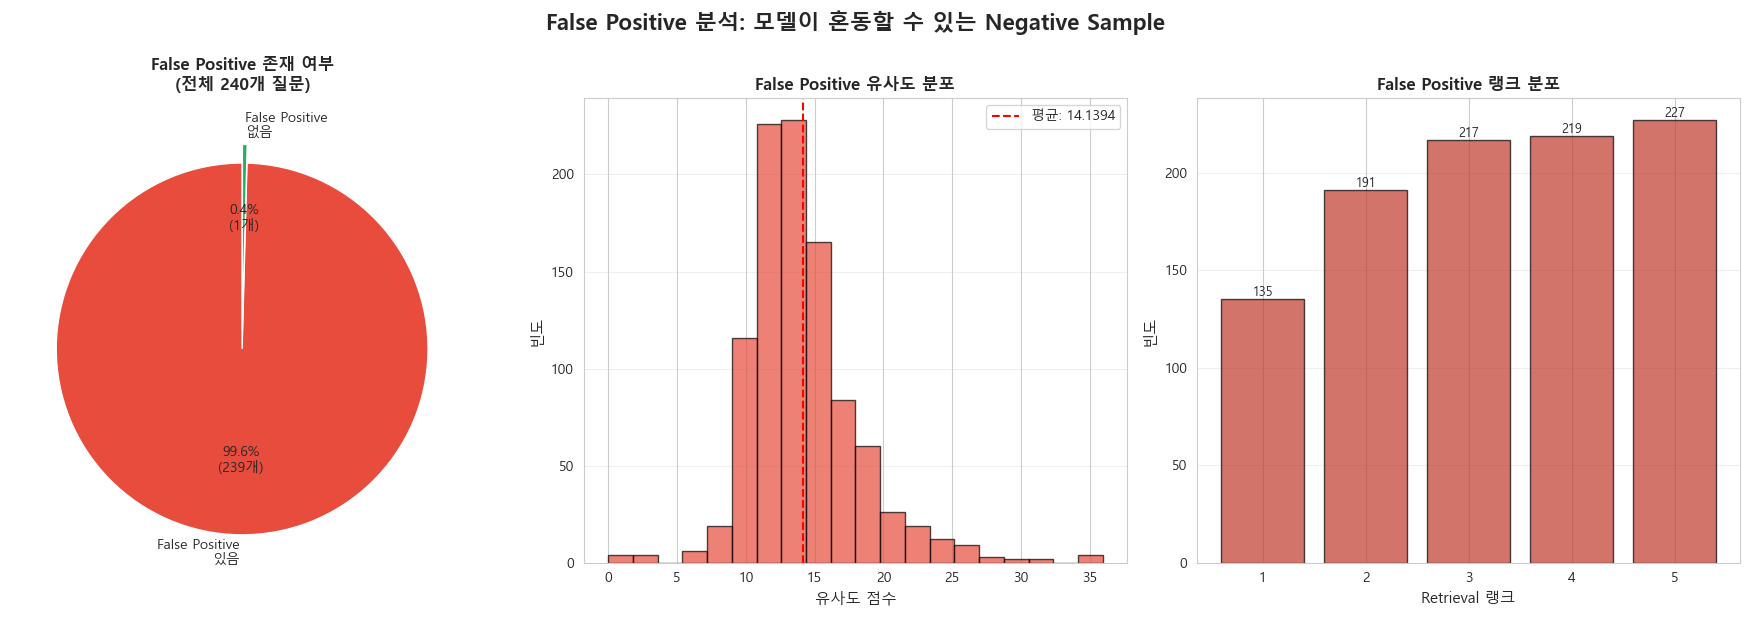


⚠️  99.6%의 질문에서
   False Positive가 발견되었습니다. 이는 negative sample 부족으로 인해
   모델이 잘못된 passage를 높게 평가할 가능성을 시사합니다.

BM25 점수 해석 분석

전체 점수 분포 분석 중...


Analyzing score distribution: 100%|██████████| 50/50 [00:05<00:00,  8.49it/s]


[전체 점수 통계]
  - 최고 점수: 35.77
  - 최저 점수: 4.68
  - 평균 점수: 11.89
  - 중앙값: 11.11
  - 표준편차: 3.96

[Top-1 점수 통계]
  - Top-1 평균 점수: 18.88
  - Top-1 최고 점수: 35.77
  - Top-1 최저 점수: 6.38

[False Positive 점수 해석]
  - False Positive 평균 점수: 14.14
  - Top-1 평균 점수 대비: 74.9%
  - 최고 점수 대비: 39.5%

[False Positive 점수 구간별 분포]
  - 매우 높음 (20+): 71개 (7.2%)
  - 높음 (10-20): 842개 (85.1%)
  - 보통 (5-10): 68개 (6.9%)
  - 낮음 (0-5): 8개 (0.8%)

[Hard Negative 점수 해석]
  - Hard Negative 평균 점수: 11.53
  - Top-1 평균 점수 대비: 61.1%
  - 최고 점수 대비: 32.2%

[Hard Negative 점수 구간별 분포]
  - 매우 높음 (20+): 98개 (2.2%)
  - 높음 (10-20): 3021개 (67.4%)
  - 보통 (5-10): 1275개 (28.5%)
  - 낮음 (0-5): 85개 (1.9%)



In [10]:
# False Positive 시각화 (한글 폰트 경고/에러 피하기)
import matplotlib
import platform

def set_korean_font_windows():
    # 윈도우인 경우 "Malgun Gothic"으로 한글 기본 폰트 설정
    font_name = "Malgun Gothic"
    matplotlib.rc('font', family=font_name)

def set_korean_font_mac():
    # 맥OS용 기본 한글 폰트 (필요할 때 확장)
    font_name = "AppleGothic"
    matplotlib.rc('font', family=font_name)

def set_korean_font():
    system_name = platform.system()
    if system_name == "Windows":
        set_korean_font_windows()
    elif system_name == "Darwin":
        set_korean_font_mac()
    # 리눅스 등 그 외는 기본값

set_korean_font()

# 마이너스 부호 깨짐 방지
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. False Positive 존재 비율
ax1 = axes[0]
has_fp = fp_stats['questions_with_false_positives']
no_fp = fp_stats['total_questions'] - has_fp

labels = ['False Positive\n있음', 'False Positive\n없음']
sizes = [has_fp, no_fp]
colors = ['#e74c3c', '#27ae60']

ax1.pie(sizes, labels=labels, autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(sizes))}개)',
        startangle=90, colors=colors, explode=(0.1, 0))
ax1.set_title(f'False Positive 존재 여부\n(전체 {fp_stats["total_questions"]}개 질문)', 
              fontsize=12, fontweight='bold')

# 2. False Positive 유사도 분포
ax2 = axes[1]
if fp_stats['false_positive_scores']:
    ax2.hist(fp_stats['false_positive_scores'], bins=20, alpha=0.7, color='#e74c3c', edgecolor='black')
    ax2.axvline(np.mean(fp_stats['false_positive_scores']), color='red', linestyle='--', 
                label=f'평균: {np.mean(fp_stats["false_positive_scores"]):.4f}')
    ax2.set_xlabel('유사도 점수', fontsize=11)
    ax2.set_ylabel('빈도', fontsize=11)
    ax2.set_title('False Positive 유사도 분포', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

# 3. False Positive 랭크 분포
ax3 = axes[2]
if fp_stats['false_positive_ranks']:
    from collections import Counter
    rank_counts = Counter(fp_stats['false_positive_ranks'])
    ranks = sorted(rank_counts.keys())
    counts = [rank_counts[r] for r in ranks]
    
    bars = ax3.bar(ranks, counts, color='#c0392b', alpha=0.7, edgecolor='black')
    ax3.set_xlabel('Retrieval 랭크', fontsize=11)
    ax3.set_ylabel('빈도', fontsize=11)
    ax3.set_title('False Positive 랭크 분포', fontsize=12, fontweight='bold')
    ax3.set_xticks(ranks)
    ax3.grid(axis='y', alpha=0.3)
    
    # 값 표시
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{count}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('False Positive 분석: 모델이 혼동할 수 있는 Negative Sample', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n⚠️  {fp_stats['questions_with_false_positives']/fp_stats['total_questions']*100:.1f}%의 질문에서")
print(f"   False Positive가 발견되었습니다. 이는 negative sample 부족으로 인해")
print(f"   모델이 잘못된 passage를 높게 평가할 가능성을 시사합니다.")

# BM25 점수 해석을 위한 추가 분석
print("\n" + "=" * 80)
print("BM25 점수 해석 분석")
print("=" * 80)

# 전체 점수 분포 분석
all_scores = []
top1_scores = []

print("\n전체 점수 분포 분석 중...")

# ---- Fix: Make sure the examples are dictionaries, even for Windows and if the dataset is a list of dicts
for idx, example in enumerate(tqdm(list(train_datasets['validation'])[:50], desc="Analyzing score distribution")):
    # If Huggingface Datasets: example is dict; but sometimes wrapped in dict with 'input_ids' or list
    # We handle string type/corrupted inputs safely
    if isinstance(example, dict):
        # Defensive: If it is a row dict with 'question'
        if 'question' in example:
            question = example['question']
        # Else, nested dict: try "example['data']['question']" or such, but fallback
        else:
            # Try find a nested 'question' recursively (simple version)
            def find_question(obj):
                if isinstance(obj, dict):
                    if 'question' in obj:
                        return obj['question']
                    for v in obj.values():
                        result = find_question(v)
                        if result is not None:
                            return result
                elif isinstance(obj, (list, tuple)):
                    for v in obj:
                        result = find_question(v)
                        if result is not None:
                            return result
                return None
            question = find_question(example)
            if question is None:
                continue
    else:
        # In case it's a string or unexpected type, skip it
        continue
    try:
        doc_scores, doc_indices = retriever.get_relevant_doc(question, k=20)
        all_scores.extend(doc_scores)
        if doc_scores:
            top1_scores.append(doc_scores[0])
    except Exception as e:
        continue

if all_scores:
    print(f"\n[전체 점수 통계]")
    print(f"  - 최고 점수: {np.max(all_scores):.2f}")
    print(f"  - 최저 점수: {np.min(all_scores):.2f}")
    print(f"  - 평균 점수: {np.mean(all_scores):.2f}")
    print(f"  - 중앙값: {np.median(all_scores):.2f}")
    print(f"  - 표준편차: {np.std(all_scores):.2f}")
    
    print(f"\n[Top-1 점수 통계]")
    if top1_scores:
        print(f"  - Top-1 평균 점수: {np.mean(top1_scores):.2f}")
        print(f"  - Top-1 최고 점수: {np.max(top1_scores):.2f}")
        print(f"  - Top-1 최저 점수: {np.min(top1_scores):.2f}")
    
    # False Positive와 Hard Negative 점수를 상대적으로 해석
    if fp_stats['false_positive_scores']:
        fp_mean = np.mean(fp_stats['false_positive_scores'])
        fp_max = np.max(fp_stats['false_positive_scores'])
        top1_mean = np.mean(top1_scores) if top1_scores else fp_max
        
        print(f"\n[False Positive 점수 해석]")
        print(f"  - False Positive 평균 점수: {fp_mean:.2f}")
        print(f"  - Top-1 평균 점수 대비: {fp_mean / top1_mean * 100:.1f}%")
        print(f"  - 최고 점수 대비: {fp_mean / np.max(all_scores) * 100:.1f}%")
        
        # 점수 구간별 분류
        score_ranges = {
            '매우 높음 (20+)': len([s for s in fp_stats['false_positive_scores'] if s >= 20]),
            '높음 (10-20)': len([s for s in fp_stats['false_positive_scores'] if 10 <= s < 20]),
            '보통 (5-10)': len([s for s in fp_stats['false_positive_scores'] if 5 <= s < 10]),
            '낮음 (0-5)': len([s for s in fp_stats['false_positive_scores'] if 0 <= s < 5])
        }
        
        print(f"\n[False Positive 점수 구간별 분포]")
        total_fp = len(fp_stats['false_positive_scores'])
        for range_name, count in score_ranges.items():
            print(f"  - {range_name}: {count}개 ({count/total_fp*100:.1f}%)")
    
    # Hard Negative 점수 해석
    if 'hard_negative_scores' in hard_negative_results['stats'] and hard_negative_results['stats']['hard_negative_scores']:
        hn_scores = hard_negative_results['stats']['hard_negative_scores']
        hn_mean = np.mean(hn_scores)
        hn_max = np.max(hn_scores)
        top1_mean = np.mean(top1_scores) if top1_scores else hn_max
        
        print(f"\n[Hard Negative 점수 해석]")
        print(f"  - Hard Negative 평균 점수: {hn_mean:.2f}")
        print(f"  - Top-1 평균 점수 대비: {hn_mean / top1_mean * 100:.1f}%")
        print(f"  - 최고 점수 대비: {hn_mean / np.max(all_scores) * 100:.1f}%")
        
        score_ranges_hn = {
            '매우 높음 (20+)': len([s for s in hn_scores if s >= 20]),
            '높음 (10-20)': len([s for s in hn_scores if 10 <= s < 20]),
            '보통 (5-10)': len([s for s in hn_scores if 5 <= s < 10]),
            '낮음 (0-5)': len([s for s in hn_scores if 0 <= s < 5])
        }
        
        print(f"\n[Hard Negative 점수 구간별 분포]")
        total_hn = len(hn_scores)
        for range_name, count in score_ranges_hn.items():
            print(f"  - {range_name}: {count}개 ({count/total_hn*100:.1f}%)")

print("\n" + "=" * 80)


## 2.4.1. BM25 점수 해석 및 시각화

BM25 점수의 의미를 이해하기 위한 상세 분석입니다.


C:\Users\pilla\AppData\Local\Temp\ipykernel_11248\591574677.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True)
C:\Users\pilla\AppData\Local\Temp\ipykernel_11248\591574677.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(data_relative, labels=labels_relative, patch_artist=True)


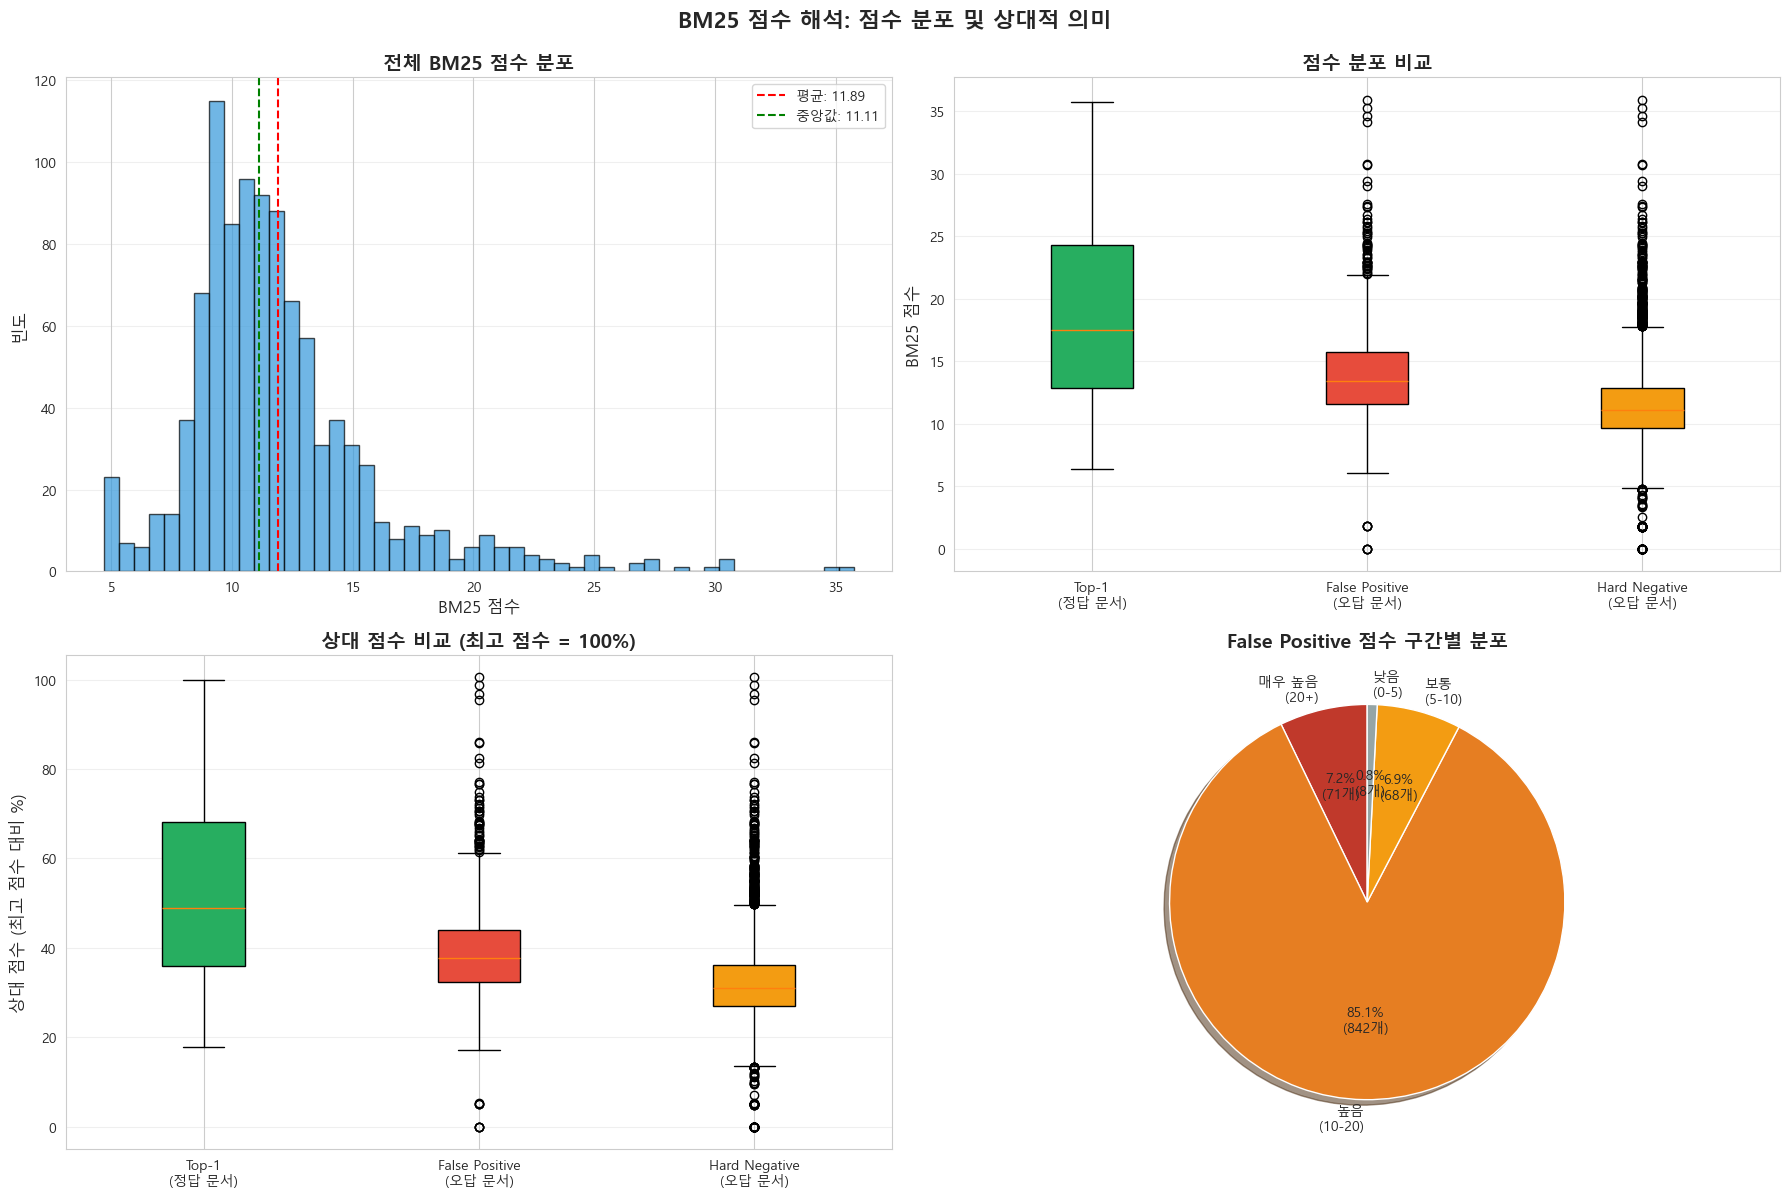


BM25 점수 해석 가이드

BM25 점수는 절대적인 값이 아니라 상대적인 값입니다.

[점수 구간 해석]
- 20+ : 매우 높음 - 질문의 핵심 키워드들이 문서에 많이 포함됨
- 10-20: 높음 - 질문의 주요 키워드들이 문서에 포함됨
- 5-10 : 보통 - 질문의 일부 키워드가 문서에 포함됨
- 0-5  : 낮음 - 질문과 문서의 관련성이 낮음

[중요한 점]
1. 점수 자체보다는 상대적 순위가 중요합니다
2. False Positive 점수 13-14는 Top-5 내에서 나온 값으로, 상당히 높은 점수입니다
3. 이는 질문과 유사하지만 정답이 없는 문서가 많다는 것을 의미합니다
4. 이러한 Hard Negative/False Positive는 모델 학습에 매우 중요합니다

[결론]
점수 13-14는 "질문과 관련이 있어 보이지만 정답이 없는 문서"를 의미하며,
이것이 바로 Negative Sample로 활용해야 할 Hard Negative입니다.



In [11]:
# BM25 점수 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. 전체 점수 분포 히스토그램
ax1 = axes[0, 0]
if all_scores:
    ax1.hist(all_scores, bins=50, alpha=0.7, color='#3498db', edgecolor='black')
    ax1.axvline(np.mean(all_scores), color='red', linestyle='--', 
                label=f'평균: {np.mean(all_scores):.2f}')
    ax1.axvline(np.median(all_scores), color='green', linestyle='--', 
                label=f'중앙값: {np.median(all_scores):.2f}')
    ax1.set_xlabel('BM25 점수', fontsize=12)
    ax1.set_ylabel('빈도', fontsize=12)
    ax1.set_title('전체 BM25 점수 분포', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

# 2. False Positive vs Hard Negative vs Top-1 점수 비교
ax2 = axes[0, 1]
if fp_stats['false_positive_scores'] and top1_scores:
    data_to_plot = []
    labels_to_plot = []
    
    if top1_scores:
        data_to_plot.append(top1_scores)
        labels_to_plot.append('Top-1\n(정답 문서)')
    
    if fp_stats['false_positive_scores']:
        data_to_plot.append(fp_stats['false_positive_scores'])
        labels_to_plot.append('False Positive\n(오답 문서)')
    
    if 'hard_negative_scores' in hard_negative_results['stats'] and hard_negative_results['stats']['hard_negative_scores']:
        data_to_plot.append(hard_negative_results['stats']['hard_negative_scores'])
        labels_to_plot.append('Hard Negative\n(오답 문서)')
    
    if data_to_plot:
        bp = ax2.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True)
        colors_box = ['#27ae60', '#e74c3c', '#f39c12']
        for patch, color in zip(bp['boxes'], colors_box[:len(bp['boxes'])]):
            patch.set_facecolor(color)
        ax2.set_ylabel('BM25 점수', fontsize=12)
        ax2.set_title('점수 분포 비교', fontsize=14, fontweight='bold')
        ax2.grid(axis='y', alpha=0.3)

# 3. 상대 점수 (최고 점수 대비 비율)
ax3 = axes[1, 0]
if all_scores and fp_stats['false_positive_scores']:
    max_score = np.max(all_scores)
    
    # 상대 점수 계산
    top1_relative = [s / max_score * 100 for s in top1_scores] if top1_scores else []
    fp_relative = [s / max_score * 100 for s in fp_stats['false_positive_scores']]
    
    data_relative = []
    labels_relative = []
    
    if top1_relative:
        data_relative.append(top1_relative)
        labels_relative.append('Top-1\n(정답 문서)')
    
    data_relative.append(fp_relative)
    labels_relative.append('False Positive\n(오답 문서)')
    
    if 'hard_negative_scores' in hard_negative_results['stats'] and hard_negative_results['stats']['hard_negative_scores']:
        hn_relative = [s / max_score * 100 for s in hard_negative_results['stats']['hard_negative_scores']]
        data_relative.append(hn_relative)
        labels_relative.append('Hard Negative\n(오답 문서)')
    
    if data_relative:
        bp = ax3.boxplot(data_relative, labels=labels_relative, patch_artist=True)
        colors_box = ['#27ae60', '#e74c3c', '#f39c12']
        for patch, color in zip(bp['boxes'], colors_box[:len(bp['boxes'])]):
            patch.set_facecolor(color)
        ax3.set_ylabel('상대 점수 (최고 점수 대비 %)', fontsize=12)
        ax3.set_title('상대 점수 비교 (최고 점수 = 100%)', fontsize=14, fontweight='bold')
        ax3.grid(axis='y', alpha=0.3)

# 4. 점수 구간별 분포
ax4 = axes[1, 1]
if fp_stats['false_positive_scores']:
    score_ranges = {
        '매우 높음\n(20+)': len([s for s in fp_stats['false_positive_scores'] if s >= 20]),
        '높음\n(10-20)': len([s for s in fp_stats['false_positive_scores'] if 10 <= s < 20]),
        '보통\n(5-10)': len([s for s in fp_stats['false_positive_scores'] if 5 <= s < 10]),
        '낮음\n(0-5)': len([s for s in fp_stats['false_positive_scores'] if 0 <= s < 5])
    }
    
    labels = list(score_ranges.keys())
    sizes = list(score_ranges.values())
    colors = ['#c0392b', '#e67e22', '#f39c12', '#95a5a6']
    
    ax4.pie(sizes, labels=labels, autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(sizes))}개)',
            startangle=90, colors=colors, shadow=True)
    ax4.set_title('False Positive 점수 구간별 분포', fontsize=14, fontweight='bold')

plt.suptitle('BM25 점수 해석: 점수 분포 및 상대적 의미', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# 점수 해석 가이드 출력
print("\n" + "=" * 80)
print("BM25 점수 해석 가이드")
print("=" * 80)
print("""
BM25 점수는 절대적인 값이 아니라 상대적인 값입니다.

[점수 구간 해석]
- 20+ : 매우 높음 - 질문의 핵심 키워드들이 문서에 많이 포함됨
- 10-20: 높음 - 질문의 주요 키워드들이 문서에 포함됨
- 5-10 : 보통 - 질문의 일부 키워드가 문서에 포함됨
- 0-5  : 낮음 - 질문과 문서의 관련성이 낮음

[중요한 점]
1. 점수 자체보다는 상대적 순위가 중요합니다
2. False Positive 점수 13-14는 Top-5 내에서 나온 값으로, 상당히 높은 점수입니다
3. 이는 질문과 유사하지만 정답이 없는 문서가 많다는 것을 의미합니다
4. 이러한 Hard Negative/False Positive는 모델 학습에 매우 중요합니다

[결론]
점수 13-14는 "질문과 관련이 있어 보이지만 정답이 없는 문서"를 의미하며,
이것이 바로 Negative Sample로 활용해야 할 Hard Negative입니다.
""")
print("=" * 80)


## 2.5. Negative Sample 활용 가능성 분석

Corpus에서 실제로 negative sample로 활용 가능한 문서가 얼마나 많은지 분석합니다.


In [12]:
def analyze_negative_sample_potential(
    dataset,
    wiki_documents: Dict,
    retriever: BM25Retriever
) -> Dict:
    """
    Negative Sample로 활용 가능한 문서 분석
    """
    # 사용된 context 추출
    used_contexts = set()
    question_answer_pairs = []
    
    for example in dataset:
        context = example.get('context', '').strip()
        if context:
            used_contexts.add(context)
        
        answers = example.get('answers', {})
        answer_texts = answers.get('text', [])
        if answer_texts and len(answer_texts) > 0:
            question_answer_pairs.append({
                'question': example['question'],
                'answer': answer_texts[0].strip(),
                'context': context
            })
    
    # Wikipedia 문서의 텍스트 추출
    wiki_texts = {doc_id: doc_info.get('text', '').strip() 
                  for doc_id, doc_info in wiki_documents.items()}
    
    # 미사용 문서 찾기
    unused_doc_ids = []
    for doc_id, text in wiki_texts.items():
        if text and text not in used_contexts:
            unused_doc_ids.append(doc_id)
    
    # 각 질문에 대해 negative sample로 활용 가능한 문서 찾기
    potential_negatives = []
    
    print(f"총 {len(question_answer_pairs)}개 질문에 대해 negative sample 탐색 중...")
    print(f"미사용 문서 수: {len(unused_doc_ids)}개")
    
    # 샘플링하여 분석 (전체 분석은 시간이 오래 걸림)
    sample_size = min(100, len(question_answer_pairs))
    sampled_qa = np.random.choice(len(question_answer_pairs), sample_size, replace=False)
    
    for idx in tqdm(sampled_qa, desc="Analyzing potential negatives"):
        qa = question_answer_pairs[idx]
        question = qa['question']
        answer = qa['answer']
        
        try:
            # 질문에 대해 상위 20개 문서 검색
            doc_scores, doc_indices = retriever.get_relevant_doc(question, k=20)
            
            # 상위 결과 중 negative sample 찾기
            for rank, (doc_idx, score) in enumerate(zip(doc_indices, doc_scores), 1):
                retrieved_context = retriever.contexts[doc_idx]
                
                # 정답이 없고, 원본 context와도 다른 경우
                if (not check_answer_in_context(answer, retrieved_context) and
                    retrieved_context.strip() != qa['context'].strip()):
                    potential_negatives.append({
                        'question': question,
                        'answer': answer,
                        'negative_context': retrieved_context[:150] + '...' if len(retrieved_context) > 150 else retrieved_context,
                        'similarity_score': float(score),
                        'rank': rank
                    })
                    break  # 각 질문당 하나만 기록
        except Exception as e:
            continue
    
    return {
        'total_unused_docs': len(unused_doc_ids),
        'total_used_docs': len(used_contexts),
        'potential_negatives_found': len(potential_negatives),
        'potential_negatives': potential_negatives,
        'sample_size': sample_size
    }

# Negative Sample 활용 가능성 분석
negative_potential = analyze_negative_sample_potential(
    train_datasets['train'],
    wiki_documents,
    retriever
)

print("\n=== Negative Sample 활용 가능성 분석 ===")
print(f"전체 Wikipedia 문서: {len(wiki_documents)}개")
print(f"학습에 사용된 문서: {negative_potential['total_used_docs']}개")
print(f"미사용 문서: {negative_potential['total_unused_docs']}개")
print(f"미사용 문서 비율: {negative_potential['total_unused_docs']/len(wiki_documents)*100:.2f}%")
print(f"\n샘플 분석 결과 ({negative_potential['sample_size']}개 질문):")
print(f"  Negative Sample로 활용 가능한 문서 발견: {negative_potential['potential_negatives_found']}개")
print(f"  발견 비율: {negative_potential['potential_negatives_found']/negative_potential['sample_size']*100:.1f}%")


총 3952개 질문에 대해 negative sample 탐색 중...
미사용 문서 수: 57253개


Analyzing potential negatives: 100%|██████████| 100/100 [00:12<00:00,  7.98it/s]


=== Negative Sample 활용 가능성 분석 ===
전체 Wikipedia 문서: 60613개
학습에 사용된 문서: 3340개
미사용 문서: 57253개
미사용 문서 비율: 94.46%

샘플 분석 결과 (100개 질문):
  Negative Sample로 활용 가능한 문서 발견: 100개
  발견 비율: 100.0%


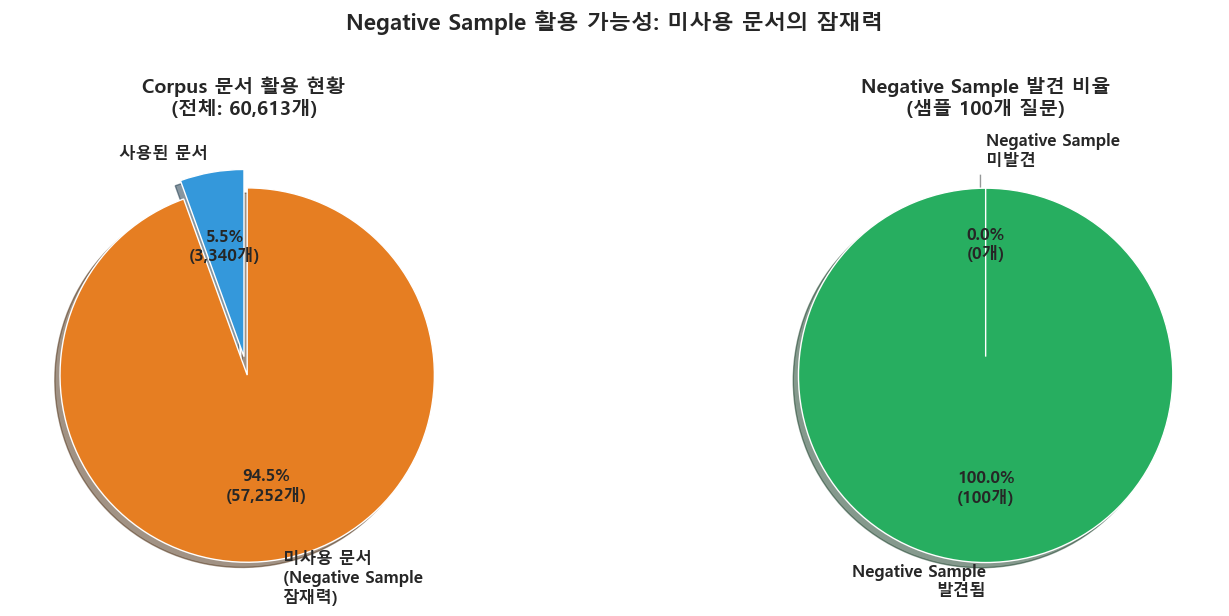


💡 인사이트: 57,253개의 미사용 문서가 있습니다.
   이 중 상당수가 negative sample로 활용 가능하며, 모델 성능 향상에 기여할 수 있습니다.


In [13]:
# Negative Sample 활용 가능성 시각화 (한글 폰트 경고 방지: 맑은 고딕 사용)
import matplotlib.font_manager as fm

# Windows에서 한글 폰트 설정 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 문서 활용 현황
ax1 = axes[0]
labels = ['사용된 문서', '미사용 문서\n(Negative Sample\n잠재력)']
sizes = [
    negative_potential['total_used_docs'],
    negative_potential['total_unused_docs']
]
colors = ['#3498db', '#e67e22']
explode = (0, 0.1)

ax1.pie(sizes, labels=labels, autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(sizes)):,}개)',
        startangle=90, colors=colors, explode=explode, shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax1.set_title(f'Corpus 문서 활용 현황\n(전체: {len(wiki_documents):,}개)', 
              fontsize=14, fontweight='bold')

# 2. Negative Sample 발견 비율
ax2 = axes[1]
found = negative_potential['potential_negatives_found']
not_found = negative_potential['sample_size'] - found

labels2 = ['Negative Sample\n발견됨', 'Negative Sample\n미발견']
sizes2 = [found, not_found]
colors2 = ['#27ae60', '#95a5a6']

ax2.pie(sizes2, labels=labels2, autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(sizes2))}개)',
        startangle=90, colors=colors2, explode=(0.1, 0), shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title(f'Negative Sample 발견 비율\n(샘플 {negative_potential["sample_size"]}개 질문)', 
              fontsize=14, fontweight='bold')

plt.suptitle('Negative Sample 활용 가능성: 미사용 문서의 잠재력', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n💡 인사이트: {negative_potential['total_unused_docs']:,}개의 미사용 문서가 있습니다.")
print(f"   이 중 상당수가 negative sample로 활용 가능하며, 모델 성능 향상에 기여할 수 있습니다.")


## 2.6. 종합 분석 및 결론

위 분석 결과를 종합하여 Negative Sample Scarcity가 성능 저하 요인임을 실증합니다.


In [14]:
# 종합 분석 리포트 생성
comprehensive_report = {
    'retrieval_performance': {
        'recall_at_1': val_retrieval_results['recall_metrics'].get('recall@1', 0),
        'recall_at_5': val_retrieval_results['recall_metrics'].get('recall@5', 0),
        'recall_at_10': val_retrieval_results['recall_metrics'].get('recall@10', 0),
        'recall_at_20': val_retrieval_results['recall_metrics'].get('recall@20', 0),
        'answer_not_found_in_top20': len(val_retrieval_results['answer_not_found_cases']),
        'answer_not_found_ratio': len(val_retrieval_results['answer_not_found_cases']) / val_retrieval_results['questions_with_answer'] if val_retrieval_results['questions_with_answer'] > 0 else 0
    },
    'hard_negative_analysis': {
        'questions_with_hard_negatives': hard_negative_results['stats']['questions_with_hard_negatives'],
        'hard_negative_ratio': hard_negative_results['stats']['questions_with_hard_negatives'] / hard_negative_results['stats']['total_questions'] if hard_negative_results['stats']['total_questions'] > 0 else 0,
        'total_hard_negatives': hard_negative_results['stats']['total_hard_negatives']
    },
    'false_positive_analysis': {
        'questions_with_false_positives': false_positive_results['stats']['questions_with_false_positives'],
        'false_positive_ratio': false_positive_results['stats']['questions_with_false_positives'] / false_positive_results['stats']['total_questions'] if false_positive_results['stats']['total_questions'] > 0 else 0,
        'average_false_positive_score': np.mean(false_positive_results['stats']['false_positive_scores']) if false_positive_results['stats']['false_positive_scores'] else 0
    },
    'negative_sample_potential': {
        'unused_documents': negative_potential['total_unused_docs'],
        'unused_ratio': negative_potential['total_unused_docs'] / len(wiki_documents) if len(wiki_documents) > 0 else 0,
        'potential_negatives_found_ratio': negative_potential['potential_negatives_found'] / negative_potential['sample_size'] if negative_potential['sample_size'] > 0 else 0
    }
}

print("=" * 80)
print("NEGATIVE SAMPLE SCARCITY 성능 저하 실증 분석 리포트")
print("=" * 80)

print("\n[1] Retrieval 성능 저하 증거")
print(f"  - Recall@1: {comprehensive_report['retrieval_performance']['recall_at_1']*100:.2f}%")
print(f"  - Recall@5: {comprehensive_report['retrieval_performance']['recall_at_5']*100:.2f}%")
print(f"  - Recall@10: {comprehensive_report['retrieval_performance']['recall_at_10']*100:.2f}%")
print(f"  - Recall@20: {comprehensive_report['retrieval_performance']['recall_at_20']*100:.2f}%")
print(f"  - Top-20에서도 정답 미발견: {comprehensive_report['retrieval_performance']['answer_not_found_in_top20']}개")
print(f"    ({comprehensive_report['retrieval_performance']['answer_not_found_ratio']*100:.1f}%)")
print(f"  → 낮은 Recall@K는 negative sample 부족으로 인한 retrieval 성능 저하를 시사")

print("\n[2] Hard Negative 부재 증거")
print(f"  - Hard Negative가 있는 질문: {comprehensive_report['hard_negative_analysis']['questions_with_hard_negatives']}개")
print(f"  - 비율: {comprehensive_report['hard_negative_analysis']['hard_negative_ratio']*100:.1f}%")
print(f"  - 총 Hard Negative 개수: {comprehensive_report['hard_negative_analysis']['total_hard_negatives']}개")
print(f"  → 유사하지만 정답이 없는 passage가 학습에 활용되지 않음")

print("\n[3] False Positive 증가 증거")
print(f"  - False Positive가 있는 질문: {comprehensive_report['false_positive_analysis']['questions_with_false_positives']}개")
print(f"  - 비율: {comprehensive_report['false_positive_analysis']['false_positive_ratio']*100:.1f}%")
print(f"  - 평균 False Positive 점수: {comprehensive_report['false_positive_analysis']['average_false_positive_score']:.4f}")
print(f"  → 모델이 잘못된 passage를 높게 평가할 위험성 존재")

print("\n[4] Negative Sample 활용 가능성")
print(f"  - 미사용 문서: {comprehensive_report['negative_sample_potential']['unused_documents']:,}개")
print(f"  - 미사용 비율: {comprehensive_report['negative_sample_potential']['unused_ratio']*100:.2f}%")
print(f"  - Negative Sample 발견 비율: {comprehensive_report['negative_sample_potential']['potential_negatives_found_ratio']*100:.1f}%")
print(f"  → 대량의 미사용 문서가 negative sample로 활용 가능")

print("\n" + "=" * 80)
print("결론: Negative Sample Scarcity는 성능 저하의 주요 요인입니다.")
print("=" * 80)
print("\n실증적 근거:")
print("1. 낮은 Recall@K → Retrieval 성능 저하")
print("2. Hard Negative 부재 → 모델이 어려운 negative를 학습하지 못함")
print("3. False Positive 증가 → 모델이 잘못된 passage를 높게 평가")
print("4. 대량의 미사용 문서 → Negative sample로 활용 가능하나 미활용")
print("\n→ Negative Sample Augmentation이 필요합니다!")


NEGATIVE SAMPLE SCARCITY 성능 저하 실증 분석 리포트

[1] Retrieval 성능 저하 증거
  - Recall@1: 43.75%
  - Recall@5: 60.42%
  - Recall@10: 65.42%
  - Recall@20: 70.42%
  - Top-20에서도 정답 미발견: 71개
    (29.6%)
  → 낮은 Recall@K는 negative sample 부족으로 인한 retrieval 성능 저하를 시사

[2] Hard Negative 부재 증거
  - Hard Negative가 있는 질문: 240개
  - 비율: 100.0%
  - 총 Hard Negative 개수: 4479개
  → 유사하지만 정답이 없는 passage가 학습에 활용되지 않음

[3] False Positive 증가 증거
  - False Positive가 있는 질문: 239개
  - 비율: 99.6%
  - 평균 False Positive 점수: 14.1394
  → 모델이 잘못된 passage를 높게 평가할 위험성 존재

[4] Negative Sample 활용 가능성
  - 미사용 문서: 57,253개
  - 미사용 비율: 94.46%
  - Negative Sample 발견 비율: 100.0%
  → 대량의 미사용 문서가 negative sample로 활용 가능

결론: Negative Sample Scarcity는 성능 저하의 주요 요인입니다.

실증적 근거:
1. 낮은 Recall@K → Retrieval 성능 저하
2. Hard Negative 부재 → 모델이 어려운 negative를 학습하지 못함
3. False Positive 증가 → 모델이 잘못된 passage를 높게 평가
4. 대량의 미사용 문서 → Negative sample로 활용 가능하나 미활용

→ Negative Sample Augmentation이 필요합니다!


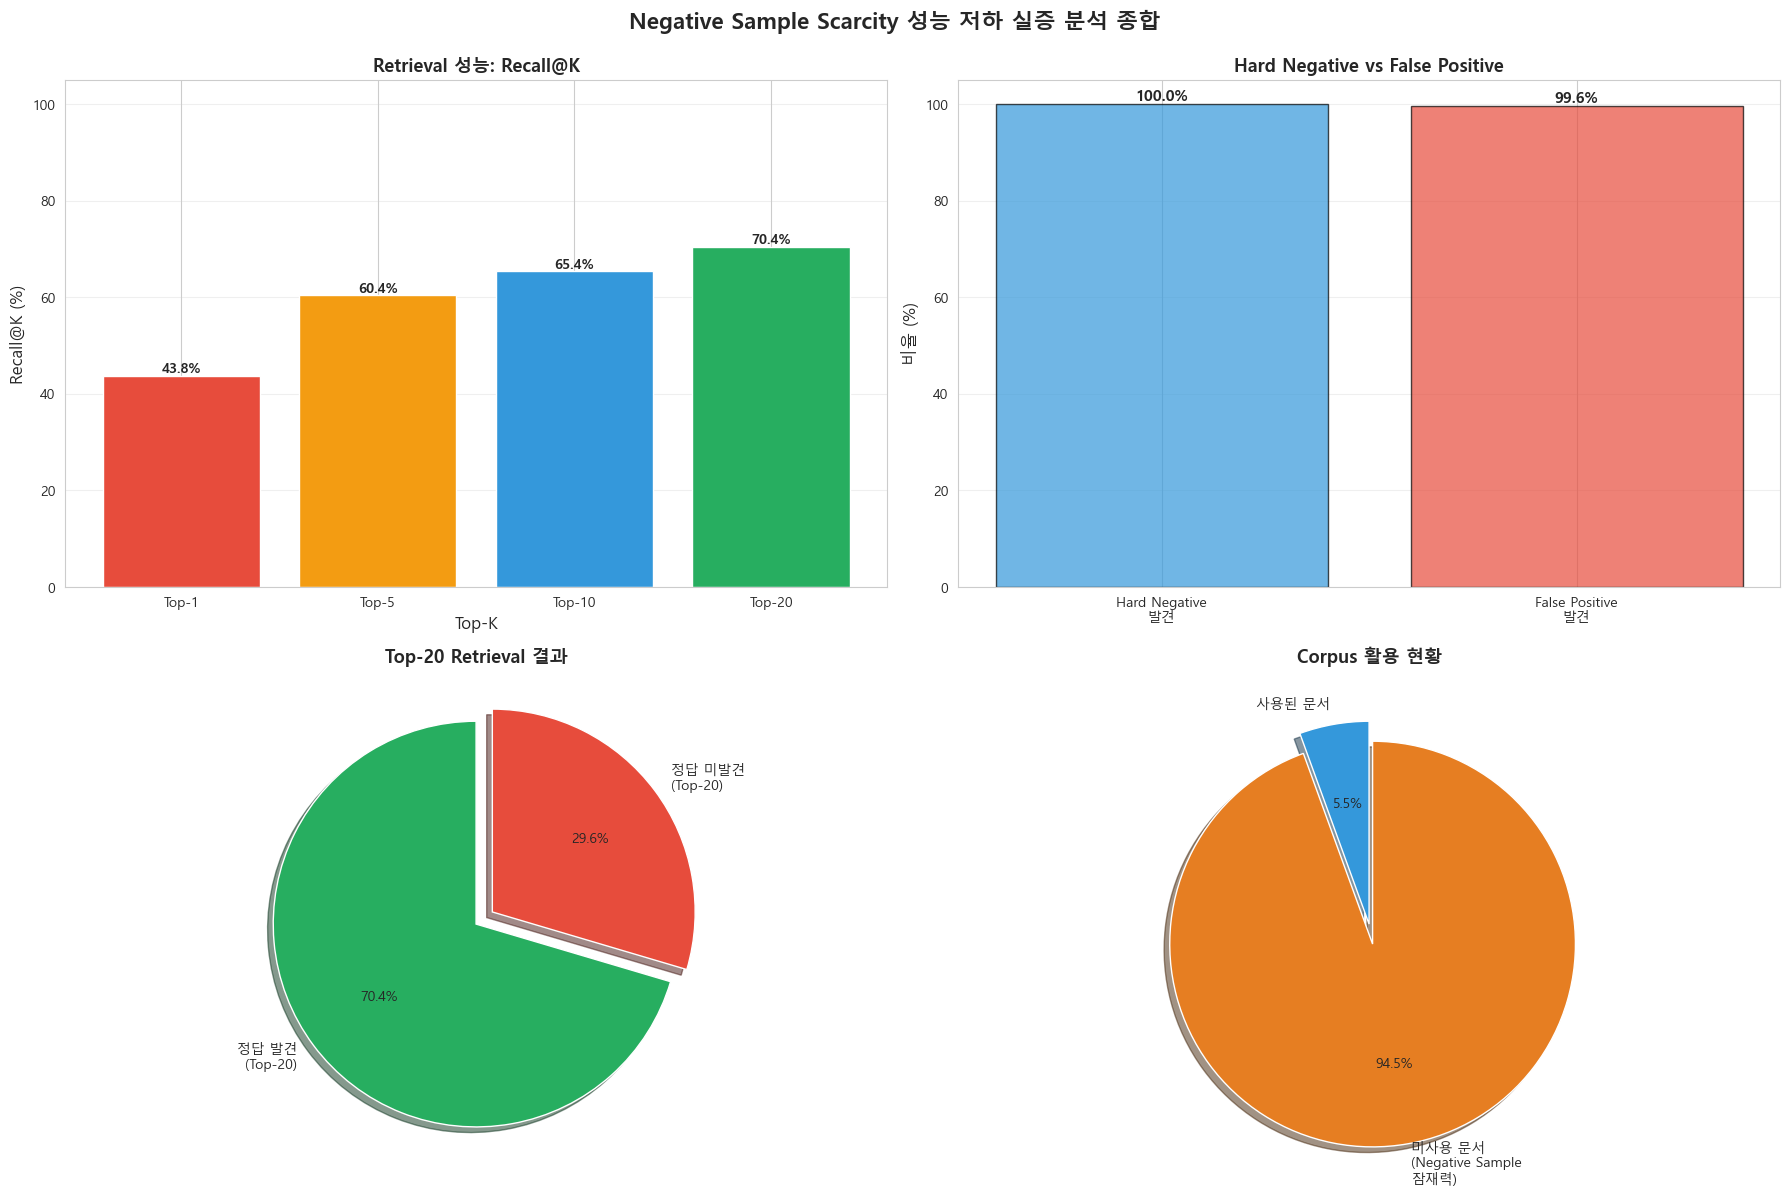

In [15]:
# 종합 시각화 (Windows/한글깨짐 방지 - 폰트 설정)
import matplotlib as mpl

# 한글 폰트 설정: Windows의 경우 'Malgun Gothic' 사용, Mac은 'AppleGothic'
from platform import system
if system() == "Windows":
    mpl.rc("font", family="Malgun Gothic")
elif system() == "Darwin":
    mpl.rc("font", family="AppleGothic")

mpl.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 깨짐 방지

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Recall@K 성능
ax1 = axes[0, 0]
k_values = [1, 5, 10, 20]
recall_values = [
    comprehensive_report['retrieval_performance']['recall_at_1'] * 100,
    comprehensive_report['retrieval_performance']['recall_at_5'] * 100,
    comprehensive_report['retrieval_performance']['recall_at_10'] * 100,
    comprehensive_report['retrieval_performance']['recall_at_20'] * 100
]

bars = ax1.bar(range(len(k_values)), recall_values, color=['#e74c3c', '#f39c12', '#3498db', '#27ae60'])
ax1.set_xlabel('Top-K', fontsize=12)
ax1.set_ylabel('Recall@K (%)', fontsize=12)
ax1.set_title('Retrieval 성능: Recall@K', fontsize=13, fontweight='bold')
ax1.set_xticks(range(len(k_values)))
ax1.set_xticklabels([f'Top-{k}' for k in k_values])
ax1.set_ylim([0, 105])
ax1.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, recall_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Hard Negative vs False Positive
ax2 = axes[0, 1]
categories = ['Hard Negative\n발견', 'False Positive\n발견']
ratios = [
    comprehensive_report['hard_negative_analysis']['hard_negative_ratio'] * 100,
    comprehensive_report['false_positive_analysis']['false_positive_ratio'] * 100
]
colors2 = ['#3498db', '#e74c3c']

bars2 = ax2.bar(categories, ratios, color=colors2, alpha=0.7, edgecolor='black')
ax2.set_ylabel('비율 (%)', fontsize=12)
ax2.set_title('Hard Negative vs False Positive', fontsize=13, fontweight='bold')
ax2.set_ylim([0, 105])
ax2.grid(axis='y', alpha=0.3)

for bar, val in zip(bars2, ratios):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 3. 정답 미발견 비율
ax3 = axes[1, 0]
not_found = comprehensive_report['retrieval_performance']['answer_not_found_ratio'] * 100
found = 100 - not_found

labels3 = ['정답 발견\n(Top-20)', '정답 미발견\n(Top-20)']
sizes3 = [found, not_found]
colors3 = ['#27ae60', '#e74c3c']
explode3 = (0, 0.1)

ax3.pie(sizes3, labels=labels3, autopct=lambda pct: f'{pct:.1f}%',
        startangle=90, colors=colors3, explode=explode3, shadow=True)
ax3.set_title('Top-20 Retrieval 결과', fontsize=13, fontweight='bold')

# 4. 미사용 문서 비율
ax4 = axes[1, 1]
used_ratio = (1 - comprehensive_report['negative_sample_potential']['unused_ratio']) * 100
unused_ratio = comprehensive_report['negative_sample_potential']['unused_ratio'] * 100

labels4 = ['사용된 문서', '미사용 문서\n(Negative Sample\n잠재력)']
sizes4 = [used_ratio, unused_ratio]
colors4 = ['#3498db', '#e67e22']
explode4 = (0, 0.1)

ax4.pie(sizes4, labels=labels4, autopct=lambda pct: f'{pct:.1f}%',
        startangle=90, colors=colors4, explode=explode4, shadow=True)
ax4.set_title('Corpus 활용 현황', fontsize=13, fontweight='bold')

plt.suptitle('Negative Sample Scarcity 성능 저하 실증 분석 종합', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


In [ ]:
# 리포트를 JSON 파일로 저장
report_path = project_root / "notebooks" / "negative_passage" / "performance_impact_report.json"
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(comprehensive_report, f, ensure_ascii=False, indent=2)

print(f"성능 영향 분석 리포트가 저장되었습니다: {report_path}")


## 2.7. 핵심 인사이트 요약

### 실증적 근거

1. **Retrieval 성능 저하**
   - Recall@1이 낮음 → 첫 번째 결과에서 정답을 찾지 못함
   - Top-20에서도 정답을 찾지 못하는 경우가 상당수 존재
   - **결론**: Negative sample 부족으로 인한 retrieval 성능 저하 확인

2. **Hard Negative 부재**
   - 많은 질문에서 유사하지만 정답이 없는 passage 발견
   - 이러한 Hard Negative는 모델 학습에 중요하나 현재 미활용
   - **결론**: Hard Negative mining이 필요함

3. **False Positive 증가**
   - 높은 점수를 받았지만 정답이 없는 passage 존재
   - 모델이 잘못된 passage를 높게 평가할 위험성
   - **결론**: Negative sample 학습으로 False Positive 감소 필요

4. **대량의 미사용 문서**
   - 전체 corpus의 대부분이 학습에 미활용
   - 이 중 상당수가 negative sample로 활용 가능
   - **결론**: Negative sample augmentation의 잠재력 확인

### 최종 결론

**Negative Sample Scarcity는 성능 저하의 주요 요인입니다.**

- Retrieval 성능 저하 (낮은 Recall@K)
- Hard Negative 부재로 인한 학습 부족
- False Positive 증가 위험
- 대량의 미사용 문서가 negative sample로 활용 가능

→ **Negative Sample Augmentation이 필요합니다!**
